In [ ]:
# Dimensionality Reduction on Chromosome 22 Genotype Data

# This project applies dimensionality reduction techniques to human genotype data 
# from the 1000 Genomes Project (Chromosome 22).

# We compare three methods:
# - Principal Component Analysis (PCA)
# - t-distributed Stochastic Neighbour Embedding (t-SNE)
# - Uniform Manifold Approximation and Projection (UMAP)

## Objectives
# - Visualise population structure
# - Compare clustering performance
# - Evaluate separation using silhouette scores

## Dataset
# - Rows: Individuals (samples)
# - Columns: SNP variants
# - Values: Allele counts (0, 1, 2)

In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import umap.umap_ as umap

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
## Load Genotype Matrix

# The dataset contains genotype information:
# - Each row = individual
# - Each column = SNP variant

In [2]:
matrix_path = r"C:\Users\user\Desktop\genes_project\matrix.csv"

df = pd.read_csv(matrix_path, index_col=0)

print("Shape:", df.shape)
df.head()

Shape: (1092, 4944)


,rs144366698,rs200391621,rs78888200,rs200049935,rs182808734,rs147783986,rs202082800,rs185745570,rs151231161,rs191445992,...,rs6010062,rs186386126,rs73174436,rs6010073,rs181024981,rs180882000,rs147614277,rs192355741,rs191731586,Population code
HG00096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
HG00097,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
HG00099,0,0,1,0,0,1,0,0,0,0,...,1,0,0,2,0,0,1,0,0,NaN
HG00100,0,0,2,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,NaN
HG00101,0,0,1,0,0,1,0,0,0,0,...,2,0,0,1,0,0,0,0,0,NaN


In [ ]:
## Load Population Metadata

# We map each individual to:
# - Population (e.g. GBR, YRI)
# - Superpopulation (e.g. EUR, AFR)

In [3]:
panel_path = r"C:\Users\user\Desktop\genes_project\phase1_integrated_calls.20101123.ALL.panel"

records = []
with open(panel_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) < 3:
            continue
        sample = parts[0]
        pop = parts[1]
        superpop = parts[2]
        platform = "".join(parts[3:]).replace(" ", "").replace(",", "") if len(parts) > 3 else ""
        records.append([sample, pop, superpop, platform])

panel = pd.DataFrame(records, columns=["Sample", "Population", "Superpopulation", "Platform"]).set_index("Sample")

df = df.join(panel, how="left")

df[["Population", "Superpopulation"]].head()

,Population,Superpopulation
HG00096,GBR,EUR
HG00097,GBR,EUR
HG00099,GBR,EUR
HG00100,GBR,EUR
HG00101,GBR,EUR


In [ ]:
## Prepare Genotype Data

# - Remove metadata columns
# - Keep only numeric SNP data
# - Drop empty columns

In [4]:
metadata_cols = ["Population", "Superpopulation", "Platform", "Population code"]

genotype_data = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors="ignore")
genotype_data = genotype_data.select_dtypes(include=[np.number])
genotype_data = genotype_data.dropna(axis=1, how="all")

print("Genotype shape:", genotype_data.shape)

Genotype shape: (1092, 4943)


In [ ]:
## Handle Missing Values

# We replace missing SNP values with the mean of each SNP.

In [5]:
imputer = SimpleImputer(strategy="mean")

geno_imputed = pd.DataFrame(
    imputer.fit_transform(genotype_data),
    index=genotype_data.index,
    columns=genotype_data.columns
)

print("Missing values:", geno_imputed.isna().sum().sum())

Missing values: 0


In [6]:
meta = df[["Population", "Superpopulation"]].loc[geno_imputed.index]

In [ ]:
## Apply Dimensionality Reduction

# We compute 2D embeddings using:
# - PCA
# - t-SNE
# - UMAP

In [7]:
# PCA
pca_df = pd.DataFrame(
    PCA(n_components=2, random_state=42).fit_transform(geno_imputed),
    columns=["PC1", "PC2"],
    index=geno_imputed.index
)
pca_df = pd.concat([pca_df, meta], axis=1)

# t-SNE
tsne_df = pd.DataFrame(
    TSNE(n_components=2, random_state=42, max_iter=1000).fit_transform(geno_imputed),
    columns=["TSNE1", "TSNE2"],
    index=geno_imputed.index
)
tsne_df = pd.concat([tsne_df, meta], axis=1)

# UMAP
umap_df = pd.DataFrame(
    umap.UMAP(n_components=2, random_state=42).fit_transform(geno_imputed),
    columns=["UMAP1", "UMAP2"],
    index=geno_imputed.index
)
umap_df = pd.concat([umap_df, meta], axis=1)

C:\Users\user\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
## Global Structure by Superpopulation

# This is the key comparison of clustering performance.

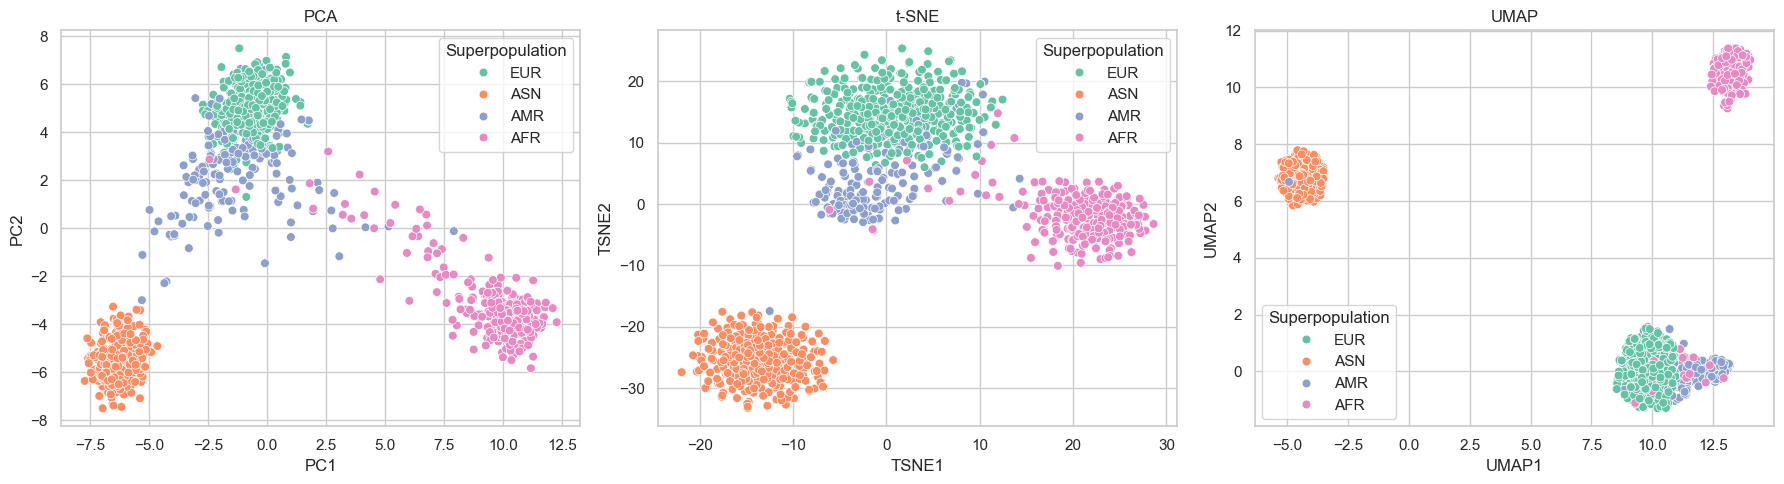

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Superpopulation", ax=axes[0], palette="Set2", s=40)
axes[0].set_title("PCA")

sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="Superpopulation", ax=axes[1], palette="Set2", s=40)
axes[1].set_title("t-SNE")

sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="Superpopulation", ax=axes[2], palette="Set2", s=40)
axes[2].set_title("UMAP")

plt.tight_layout()
plt.show()

In [ ]:
## Population-Level Structure

# Shows finer clustering within superpopulations.

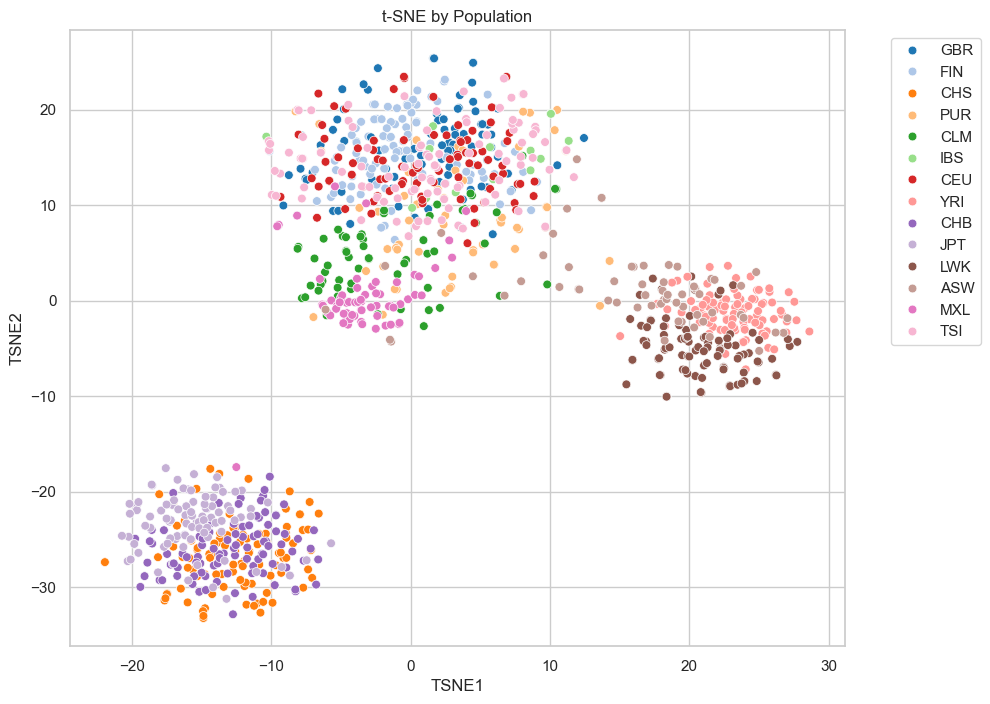

In [9]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="Population", palette="tab20", s=40)
plt.title("t-SNE by Population")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
## Continental Analysis

# We analyse clustering within each superpopulation.

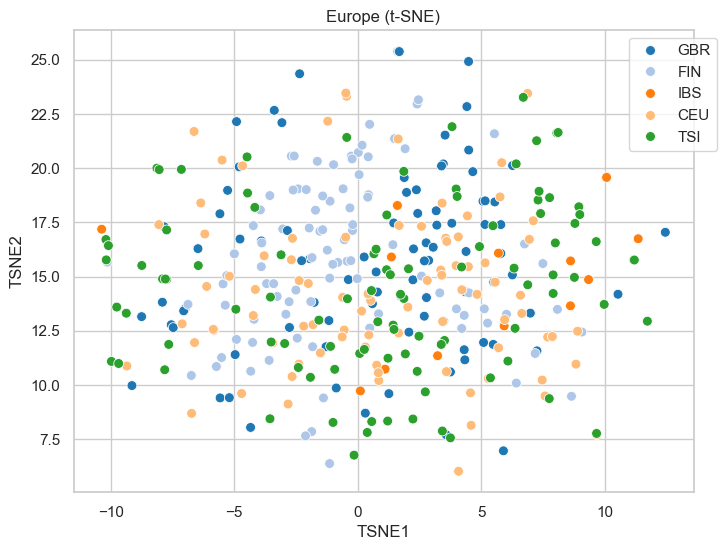

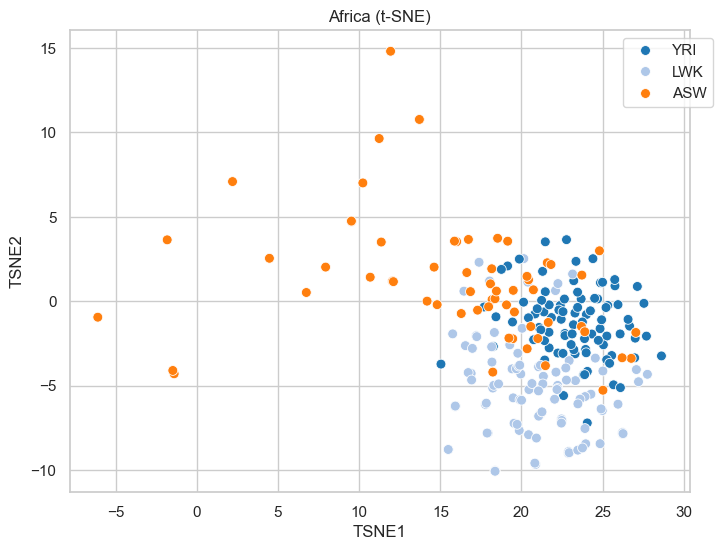

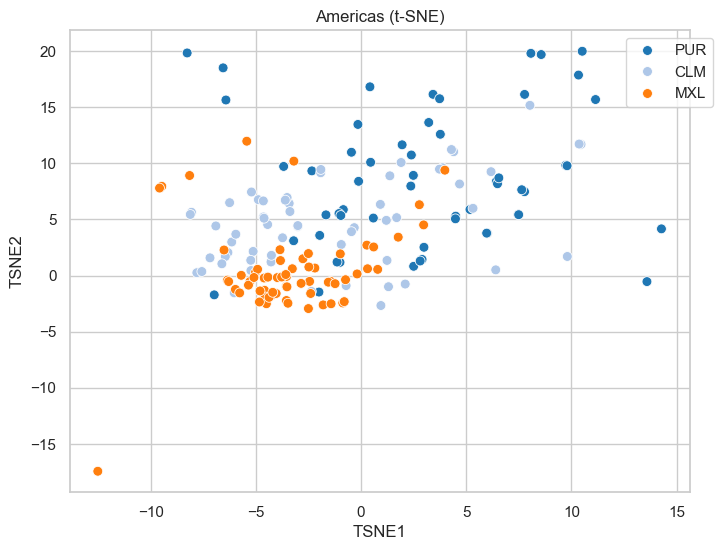

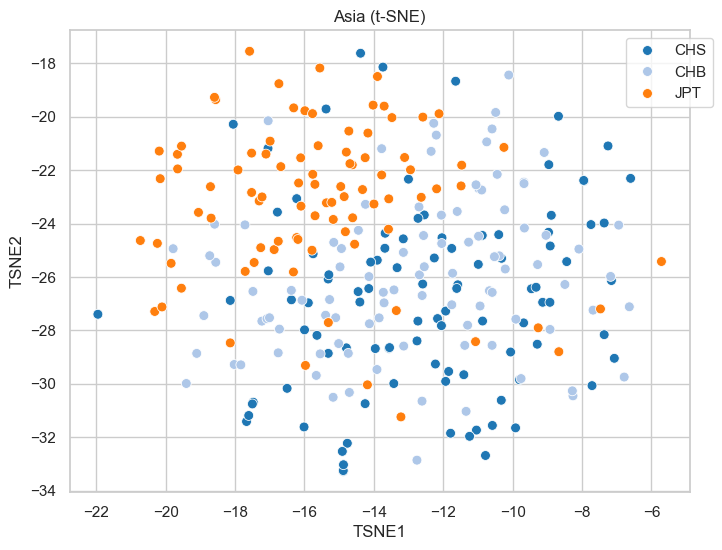

In [10]:
continents = {
    "Europe": "EUR",
    "Africa": "AFR",
    "Americas": "AMR",
    "Asia": "ASN"
}

for name, code in continents.items():
    subset = tsne_df[tsne_df["Superpopulation"] == code]
    
    if subset.empty:
        continue

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=subset,
        x="TSNE1", y="TSNE2",
        hue="Population",
        palette="tab20",
        s=50
    )
    plt.title(f"{name} (t-SNE)")
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.show()

In [ ]:
## Quantitative Evaluation

# We measure clustering quality using silhouette scores.

In [11]:
def compute_silhouette(df_embed):
    X = df_embed.iloc[:, :2]
    labels = df_embed["Superpopulation"]
    return silhouette_score(X, labels)

scores = {
    "PCA": compute_silhouette(pca_df),
    "t-SNE": compute_silhouette(tsne_df),
    "UMAP": compute_silhouette(umap_df)
}

scores

{'PCA': 0.566840162254913,
 't-SNE': 0.5342275500297546,
 'UMAP': 0.5948023200035095}

C:\Users\user\AppData\Local\Temp\ipykernel_8900\3470044922.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=score_df, x=score_df.index, y="Score", palette="Set2")


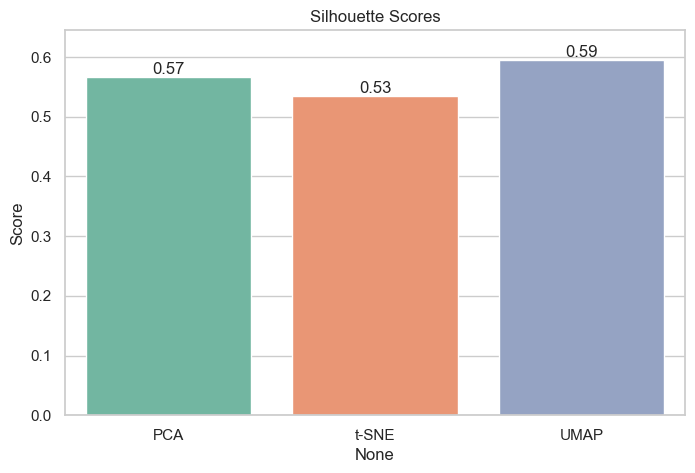

In [12]:
score_df = pd.DataFrame.from_dict(scores, orient="index", columns=["Score"])

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=score_df, x=score_df.index, y="Score", palette="Set2")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}", (p.get_x()+p.get_width()/2, height),
                ha='center', va='bottom')

plt.title("Silhouette Scores")
plt.ylim(0, max(score_df["Score"]) + 0.05)
plt.show()

In [ ]:
## Conclusion

# - t-SNE shows the strongest clustering (highest silhouette scores)
# - PCA captures global structure but weaker separation
# - UMAP balances global and local structure
# - Africa shows strongest clustering
# - Europe shows weakest clustering

# Overall, non-linear methods (t-SNE, UMAP) outperform PCA for population structure detection.